In [2]:
"""
Difference-in-Discontinuities (DiD-RD) Analysis
EU Structural Funds → Single-Bidder Procurement Corruption
Estimator : Fractional Logit (Papke-Wooldridge 1996)
           with local polynomial kernel weighting
NUTS2 Regional Level | Cycles 2007-2013 and 2014-2020
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit          # logistic / sigmoid
from scipy import stats

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# PATHS & CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR  = '/Users/matei/Documents/Classes/Economics/ECO 358R/Paper Proposal #1 (EU Aid v. Single Bids)/Data/Cleaned Data/'
OUT_DIR   = '/Users/matei/Documents/Classes/Economics/ECO 358R/Paper Proposal #1 (EU Aid v. Single Bids)/Data/Cleaned Data/output/'

TED_PATH  = DATA_DIR + "TED_Master_Cleaned_2006_2020.csv"
GDP_PATH  = DATA_DIR + "GDP_per_capita_PPS.xlsx"
GDP_HIST  = DATA_DIR + "nama_10r_2gdp__custom_21092031_spreadsheet.xlsx"
EDU_PATH  = DATA_DIR + "Education.xlsx"
POP_PATH  = DATA_DIR + "Population_density_by_NUTS2.xlsx"
SVC_PATH  = DATA_DIR + "Final_Service_Controls.xlsx"
AGRI_PATH = DATA_DIR + "Final_Agri_Controls.xlsx"

CUTOFF = 75.0
EU_PREFIXES = [
    "AT","BE","BG","CY","CZ","DE","DK","EE","EL","ES","FI","FR",
    "GR","HR","HU","IE","IT","LT","LU","LV","MT","NL","PL","PT",
    "RO","SE","SI","SK",
]
CONTROLS = ["educ_share","log_pop_density","Service_Share","Agriculture_Share",
            "dist_brussels_km","dist_capital_km","post_communist","mediterranean","terrain_ruggedness",
            "gov_effectiveness_norm","unemployment"
            ]

PALETTE = {
    "c1":      "#C0392B",
    "c2":      "#2980B9",
    "did":     "#8E44AD",
    "neutral": "#7F8C8D",
    "accent":  "#F39C12",
    "fit_l":   "#922B21",
    "fit_r":   "#1A5276",
}

# ─────────────────────────────────────────────────────────────────────────────
# 1. LOAD & CLEAN ALL DATA
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 – Loading and cleaning data")
print("=" * 70)

# ── TED procurement ──────────────────────────────────────────────────────────
ted = pd.read_csv(TED_PATH, dtype={"TAL_LOCATION_NUTS": str})
ted["single_bidder"] = (ted["NUMBER_OFFERS"] == 1).astype(int)
ted_agg = (
    ted.groupby(["TAL_LOCATION_NUTS", "YEAR"])
    .agg(
        total_contracts   = ("NUMBER_OFFERS",  "count"),
        single_bidder_n   = ("single_bidder",  "sum"),
        eu_funded_share   = ("B_EU_FUNDS", lambda x: (x == "Y").sum() / len(x)),
    )
    .reset_index()
)
ted_agg["sbr"] = ted_agg["single_bidder_n"] / ted_agg["total_contracts"]
print(f"  TED: {ted_agg.shape[0]} region-year obs | overall SBR = {ted_agg['sbr'].mean():.3f}")

# ── Historical GDP 2000-2002 (Cycle 1 forcing variable) ──────────────────────
df_raw = pd.read_excel(GDP_HIST, header=None)
hist = df_raw.iloc[9:, [0, 1, 3, 5]].copy()
hist.columns = ["region_name", "gdp_2000", "gdp_2001", "gdp_2002"]
hist["region_name"] = hist["region_name"].astype(str).str.strip()
junk = ["Extra-Regio", "Special value", "Observation flags", ":", "b", "nan"]
hist = hist[~hist["region_name"].apply(lambda x: any(str(x).startswith(j) for j in junk))]
for c in ["gdp_2000", "gdp_2001", "gdp_2002"]:
    hist[c] = pd.to_numeric(hist[c].astype(str).str.replace(":", ""), errors="coerce")
hist["ref_gdp_c1"] = hist[["gdp_2000", "gdp_2001", "gdp_2002"]].mean(axis=1)

# Map region names → NUTS2 codes via main GDP file
gdp_main = pd.read_excel(GDP_PATH)
gdp_main["PPS"]    = pd.to_numeric(gdp_main["PPS"], errors="coerce")
gdp_main["Region"] = gdp_main["Region"].str.strip()
nuts_lu = gdp_main[["Region", "TAL_LOCATION_NUTS"]].drop_duplicates("Region")

hist = hist.merge(nuts_lu, left_on="region_name", right_on="Region", how="left")
hist = hist[hist["ref_gdp_c1"].notna() & hist["TAL_LOCATION_NUTS"].notna()]
hist = hist[["TAL_LOCATION_NUTS", "ref_gdp_c1"]].rename(columns={"TAL_LOCATION_NUTS": "nuts2"})
print(f"  Historical GDP (2000-2002): {len(hist)} regions with valid data")

# ── Cycle 2 reference GDP: average 2007-2009 ─────────────────────────────────
c2_ref = (
    gdp_main[gdp_main["YEAR"].isin([2007, 2008, 2009])]
    .groupby("TAL_LOCATION_NUTS")["PPS"]
    .mean()
    .reset_index()
    .rename(columns={"TAL_LOCATION_NUTS": "nuts2", "PPS": "ref_gdp_c2"})
)
print(f"  Cycle 2 ref GDP (2007-2009): {len(c2_ref)} regions")

# ── Time-varying GDP ──────────────────────────────────────────────────────────
gdp_tv = gdp_main[["TAL_LOCATION_NUTS", "YEAR", "PPS"]].rename(
    columns={"TAL_LOCATION_NUTS": "nuts2", "YEAR": "year", "PPS": "gdp_pps"}
)

# ── Covariates ────────────────────────────────────────────────────────────────
def load_cov(path, val_col, new_col):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()
    year_col  = [c for c in df.columns if "year" in c.lower() or "YEAR" in c][0]
    nuts_col  = [c for c in df.columns if "NUTS" in c.upper()][0]
    df[val_col] = pd.to_numeric(df[val_col], errors="coerce")
    return df[[nuts_col, year_col, val_col]].rename(
        columns={nuts_col: "nuts2", year_col: "year", val_col: new_col}
    )

edu  = load_cov(EDU_PATH,  "Education",         "educ_share")
pop  = load_cov(POP_PATH,  "Pop_Dens",          "pop_density")
svc  = load_cov(SVC_PATH,  "Service_Share",     "Service_Share")
agri = load_cov(AGRI_PATH, "Agriculture_Share", "Agriculture_Share")

# ── Geographic controls ──────────────────────────────────────────────────────
geo_controls = pd.read_csv(DATA_DIR + "nuts2_geographic_controls.csv")
print(f"  Geographic controls: {len(geo_controls)} regions")

# ── Government effectiveness ──────────────────────────────────────────────────
gov_eff = pd.read_csv(DATA_DIR + "gov_effectiveness.csv")
print(f"  Government effectiveness: {len(gov_eff)} countries")

# ── Unemployment ──────────────────────────────────────────────────────────────
unemployment = pd.read_csv(DATA_DIR + "unemployment_by_nuts2.csv")
print(f"  Unemployment: {len(unemployment)} regions")

# ─────────────────────────────────────────────────────────────────────────────
# 2. BUILD CROSS-SECTIONAL DATASETS PER CYCLE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 2 – Building cycle-level cross-sections")
print("=" * 70)

def build_cross_section(ted_agg, ref_gdp_df, ref_col, year_range, cycle_id):
    years  = list(range(year_range[0], year_range[1] + 1))
    sub    = ted_agg[ted_agg["YEAR"].isin(years)].copy()
    sub.rename(columns={"TAL_LOCATION_NUTS": "nuts2", "YEAR": "year"}, inplace=True)

    # Collapse to region-level means across the cycle
    panel = sub.groupby("nuts2").agg(
        sbr             = ("sbr",           "mean"),
        total_contracts = ("total_contracts","sum"),
    ).reset_index()

    # Attach reference GDP, derive running variable and treatment
    panel = panel.merge(ref_gdp_df[["nuts2", ref_col]], on="nuts2", how="inner")
    panel["running_var"] = panel[ref_col] - CUTOFF
    panel["treatment"]   = (panel[ref_col] < CUTOFF).astype(int)
    panel["cycle"]       = cycle_id
    panel["cycle_post"]  = int(cycle_id == 2)   # 0 = C1, 1 = C2 (for DiD)

    # Average controls across cycle
    for df, col in [(edu,"educ_share"), (pop,"pop_density"),
                    (svc,"Service_Share"), (agri,"Agriculture_Share")]:
        sub_c = df[df["year"].isin(years)].groupby("nuts2")[col].mean().reset_index()
        panel = panel.merge(sub_c, on="nuts2", how="left")

    panel["log_pop_density"] = np.log1p(panel["pop_density"])

    # Merge geographic controls
    panel = panel.merge(geo_controls, on="nuts2", how="left")

    # Merge government effectiveness (country-level, cycle-specific)
    panel['country_code'] = panel['nuts2'].str[:2]
    if cycle_id == 1:
        panel = panel.merge(gov_eff[['country_code', 'gov_effectiveness_c1_norm']],
                          on='country_code', how='left')
        panel = panel.rename(columns={'gov_effectiveness_c1_norm': 'gov_effectiveness_norm'})
    else:  # cycle_id == 2
        panel = panel.merge(gov_eff[['country_code', 'gov_effectiveness_c2_norm']],
                          on='country_code', how='left')
        panel = panel.rename(columns={'gov_effectiveness_c2_norm': 'gov_effectiveness_norm'})

    # Merge unemployment (region-level, cycle-specific)
    if cycle_id == 1:
        panel = panel.merge(unemployment[['nuts2', 'unemployment_c1']],
                          on='nuts2', how='left')
        panel = panel.rename(columns={'unemployment_c1': 'unemployment'})
    else:  # cycle_id == 2
        panel = panel.merge(unemployment[['nuts2', 'unemployment_c2']],
                          on='nuts2', how='left')
        panel = panel.rename(columns={'unemployment_c2': 'unemployment'})

    # EU only, drop 160 unmatched TED regions
    panel = panel[panel["nuts2"].str[:2].isin(EU_PREFIXES)]
    panel = panel.dropna(subset=["sbr", "running_var"])
    return panel

cs_c1 = build_cross_section(ted_agg, hist,  "ref_gdp_c1", (2007, 2013), cycle_id=1)
cs_c2 = build_cross_section(ted_agg, c2_ref,"ref_gdp_c2", (2014, 2020), cycle_id=2)

print(f"  Cycle 1: {len(cs_c1)} regions | treated={cs_c1['treatment'].sum()} | control={(cs_c1['treatment']==0).sum()}")
print(f"  Cycle 2: {len(cs_c2)} regions | treated={cs_c2['treatment'].sum()} | control={(cs_c2['treatment']==0).sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# BALANCED PANEL RESTRICTION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("BALANCED PANEL RESTRICTION")
print("=" * 70)

# Identify regions present in BOTH cycles
c1_regions = set(cs_c1['nuts2'])
c2_regions = set(cs_c2['nuts2'])

common_regions = c1_regions & c2_regions  # Intersection
c1_only = c1_regions - c2_regions
c2_only = c2_regions - c1_regions

print(f"\n  Original samples:")
print(f"    Cycle 1: {len(c1_regions)} regions")
print(f"    Cycle 2: {len(c2_regions)} regions")
print(f"\n  Overlap:")
print(f"    Appear in both cycles: {len(common_regions)} regions")
print(f"    C1 only: {len(c1_only)} regions")
print(f"    C2 only: {len(c2_only)} regions")

if len(c2_only) > 0:
    print(f"\n  Regions in C2 but not C1 (first 20):")
    print(f"    {sorted(c2_only)[:20]}")

# Restrict both datasets to common regions
cs_c1_original = cs_c1.copy()  # Save original for comparison if needed
cs_c2_original = cs_c2.copy()

cs_c1 = cs_c1[cs_c1['nuts2'].isin(common_regions)].copy()
cs_c2 = cs_c2[cs_c2['nuts2'].isin(common_regions)].copy()

# Verify the restriction worked
assert len(cs_c1) == len(common_regions), "C1 filtering failed"
assert len(cs_c2) == len(common_regions), "C2 filtering failed"
assert set(cs_c1['nuts2']) == set(cs_c2['nuts2']), "Region sets don't match"

print(f"\n  ✓ Balanced panel created:")
print(f"    Cycle 1: {len(cs_c1)} regions | treated={cs_c1['treatment'].sum()} | control={(cs_c1['treatment']==0).sum()}")
print(f"    Cycle 2: {len(cs_c2)} regions | treated={cs_c2['treatment'].sum()} | control={(cs_c2['treatment']==0).sum()}")
print(f"    Regions dropped from C1: {len(c1_only)}")
print(f"    Regions dropped from C2: {len(c2_only)}")
print(f"    Sample reduction: -{len(c2_only)} observations ({100*len(c2_only)/(len(c1_only)+len(c2_only)+2*len(common_regions)):.1f}%)")

# Check boundary values — determines fractional logit vs beta
print("\n  SBR boundaries: zeros={}, ones={}".format(
    (cs_c1['sbr']==0).sum() + (cs_c2['sbr']==0).sum(),
    (cs_c1['sbr']==1).sum() + (cs_c2['sbr']==1).sum()
))
print("  → Fractional logit (Papke-Wooldridge) selected: handles exact 0s and 1s")

# ─────────────────────────────────────────────────────────────────────────────
# 3. FRACTIONAL LOGIT ESTIMATOR
# ─────────────────────────────────────────────────────────────────────────────

def fl_loglik(beta, X, y, w):
    """Weighted quasi-log-likelihood for fractional logit (Papke-Wooldridge)."""
    mu  = expit(X @ beta)
    mu  = np.clip(mu, 1e-10, 1 - 1e-10)
    ll  = y * np.log(mu) + (1 - y) * np.log(1 - mu)
    return -np.sum(w * ll)

def fl_grad(beta, X, y, w):
    mu  = expit(X @ beta)
    mu  = np.clip(mu, 1e-10, 1 - 1e-10)
    res = y - mu
    return -X.T @ (w * res)

def fl_hessian(beta, X, w):
    mu    = expit(X @ beta)
    mu    = np.clip(mu, 1e-10, 1 - 1e-10)
    diag  = w * mu * (1 - mu)
    return X.T @ (diag[:, None] * X)

def fractional_logit_wls(X, y, w):
    """
    Papke-Wooldridge (1996) fractional logit via BFGS.
    Returns: coef, robust sandwich SE (QMLE-robust), fitted values.
    """
    n, k = X.shape
    beta0 = np.zeros(k)
    res = minimize(fl_loglik, beta0, jac=fl_grad, args=(X, y, w),
                   method="BFGS", options={"maxiter": 500, "gtol": 1e-6})
    beta = res.x
    mu   = expit(X @ beta)
    mu   = np.clip(mu, 1e-10, 1 - 1e-10)

    # Robust sandwich variance (Huber-White for QMLE)
    H   = fl_hessian(beta, X, w)
    eps = (y - mu)
    B   = X.T @ ((w * eps)[:, None] * X * (w * eps)[:, None])  # outer product meat
    # More numerically stable meat:
    meat = np.zeros((k, k))
    for i in range(n):
        g = w[i] * eps[i] * X[i]
        meat += np.outer(g, g)
    try:
        H_inv = np.linalg.inv(H)
        vcov  = H_inv @ meat @ H_inv
    except np.linalg.LinAlgError:
        vcov  = np.linalg.pinv(H) @ meat @ np.linalg.pinv(H)
    se    = np.sqrt(np.diag(vcov))
    return beta, se, mu

def significance_stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def triangular_kernel(u):
    return np.maximum(1 - np.abs(u), 0)

def rot_bandwidth(x, y):
    """Rule-of-thumb bandwidth (Imbens-Kalyanaraman 2012 style)."""
    valid = np.isfinite(x) & np.isfinite(y)
    n = valid.sum()
    h = 2.702 * np.std(x[valid]) * n ** (-1 / 5)
    return max(h, 8.0)

# ─────────────────────────────────────────────────────────────────────────────
# 4. LOCAL FRACTIONAL LOGIT RDD
# ─────────────────────────────────────────────────────────────────────────────

def rdd_fl(df, bw=None, poly_order=1, controls=None, label=""):
    """
    Local fractional logit RDD with triangular kernel.
    Treatment effect τ is reported as:
      - raw coefficient on treatment dummy (log-odds scale)
      - Average Partial Effect (APE) on the probability scale
    """
    df = df.dropna(subset=["sbr", "running_var"]).copy()
    x  = df["running_var"].values
    y  = df["sbr"].values

    if bw is None:
        bw = rot_bandwidth(x, y)

    mask = np.abs(x) <= bw
    df_w = df[mask].copy()
    xw   = df_w["running_var"].values
    yw   = df_w["sbr"].values
    T    = df_w["treatment"].values
    kw   = triangular_kernel(xw / bw)

    cols = [np.ones(len(xw)), T, xw, T * xw]
    if poly_order >= 2:
        cols += [xw ** 2, T * xw ** 2]
    if controls:
        for c in controls:
            if c in df_w.columns:
                cv  = df_w[c].values.astype(float)
                cv  = (cv - np.nanmean(cv)) / (np.nanstd(cv) + 1e-8)
                cols.append(cv)

    valid = (np.all([np.isfinite(c) for c in cols], axis=0)
             & np.isfinite(yw) & np.isfinite(kw))
    X_mat = np.column_stack([c[valid] for c in cols])
    y_fit = yw[valid]
    w_fit = kw[valid]
    n_obs = int(valid.sum())

    beta, se, mu_hat = fractional_logit_wls(X_mat, y_fit, w_fit)

    tau    = beta[1]
    tau_se = se[1]
    t_val  = tau / tau_se
    p_val  = 2 * stats.norm.sf(abs(t_val))   # z-test for QMLE

    ci_lo  = tau - 1.96 * tau_se
    ci_hi  = tau + 1.96 * tau_se

    # Average Partial Effect: E[Λ'(xβ)] * τ  where Λ' = mu(1-mu)
    ape = np.mean(mu_hat * (1 - mu_hat)) * tau
    ape_se = np.mean(mu_hat * (1 - mu_hat)) * tau_se

    # Pseudo R² (McFadden)
    null_mu = np.mean(y_fit)
    null_mu = np.clip(null_mu, 1e-10, 1 - 1e-10)
    ll_null = np.sum(w_fit * (y_fit * np.log(null_mu) + (1 - y_fit) * np.log(1 - null_mu)))
    ll_fit  = np.sum(w_fit * (y_fit * np.log(np.clip(mu_hat, 1e-10, 1-1e-10))
                              + (1 - y_fit) * np.log(np.clip(1 - mu_hat, 1e-10, 1-1e-10))))
    pseudo_r2 = 1 - ll_fit / (ll_null + 1e-12)

    return {
        "label":     label,
        "bw":        round(bw, 2),
        "n_obs":     n_obs,
        "tau":       tau,
        "se":        tau_se,
        "t_stat":    t_val,
        "p_value":   p_val,
        "ci_lo":     ci_lo,
        "ci_hi":     ci_hi,
        "ape":       ape,
        "ape_se":    ape_se,
        "ape_ci_lo": ape - 1.96 * ape_se,
        "ape_ci_hi": ape + 1.96 * ape_se,
        "pseudo_r2": pseudo_r2,
        "stars":     significance_stars(p_val),
        "beta":      beta,
        "se_all":    se,
        "mu_hat":    mu_hat,
        "x_in_bw":   xw[valid],
        "y_in_bw":   y_fit,
        "T_in_bw":   T[valid],
        "w_in_bw":   w_fit,
    }

# ─────────────────────────────────────────────────────────────────────────────
# 4b. DONUT RDD (exclude observations near cutoff)
# ─────────────────────────────────────────────────────────────────────────────

def rdd_fl_donut(df, donut_width=0, bw=None, poly_order=1, controls=None, label=""):
    """
    Donut RDD: exclude observations within ±donut_width of the cutoff,
    then estimate the discontinuity by extrapolating from farther away.

    donut_width=0 → standard RDD (no exclusion)
    donut_width=5 → exclude regions with |running_var| < 5
    """
    df = df.dropna(subset=["sbr", "running_var"]).copy()

    # Exclude donut region
    df_donut = df[np.abs(df["running_var"]) >= donut_width].copy()

    if len(df_donut) < 20:
        return {
            "label": label, "donut_width": donut_width, "bw": np.nan,
            "n_obs": len(df_donut), "n_excluded": len(df) - len(df_donut),
            "tau": np.nan, "se": np.nan, "p_value": np.nan,
            "ape": np.nan, "ape_se": np.nan, "pseudo_r2": np.nan, "stars": ""
        }

    x = df_donut["running_var"].values
    y = df_donut["sbr"].values

    if bw is None:
        bw = rot_bandwidth(x, y)

    mask = np.abs(x) <= bw
    df_w = df_donut[mask].copy()
    xw   = df_w["running_var"].values
    yw   = df_w["sbr"].values
    T    = df_w["treatment"].values
    kw   = triangular_kernel(xw / bw)

    cols = [np.ones(len(xw)), T, xw, T * xw]
    if poly_order >= 2:
        cols += [xw ** 2, T * xw ** 2]
    if controls:
        for c in controls:
            if c in df_w.columns:
                cv  = df_w[c].values.astype(float)
                cv  = (cv - np.nanmean(cv)) / (np.nanstd(cv) + 1e-8)
                cols.append(cv)

    valid = (np.all([np.isfinite(c) for c in cols], axis=0)
             & np.isfinite(yw) & np.isfinite(kw))
    X_mat = np.column_stack([c[valid] for c in cols])
    y_fit = yw[valid]
    w_fit = kw[valid]
    n_obs = int(valid.sum())

    if n_obs < 15:
        return {
            "label": label, "donut_width": donut_width, "bw": bw,
            "n_obs": n_obs, "n_excluded": len(df) - len(df_donut),
            "tau": np.nan, "se": np.nan, "p_value": np.nan,
            "ape": np.nan, "ape_se": np.nan, "pseudo_r2": np.nan, "stars": ""
        }

    beta, se, mu_hat = fractional_logit_wls(X_mat, y_fit, w_fit)

    tau    = beta[1]
    tau_se = se[1]
    t_val  = tau / tau_se
    p_val  = 2 * stats.norm.sf(abs(t_val))

    ape    = np.mean(mu_hat * (1 - mu_hat)) * tau
    ape_se = np.mean(mu_hat * (1 - mu_hat)) * tau_se

    null_mu = np.clip(np.mean(y_fit), 1e-10, 1-1e-10)
    ll_null = np.sum(w_fit * (y_fit * np.log(null_mu) + (1-y_fit) * np.log(1-null_mu)))
    ll_fit  = np.sum(w_fit * (y_fit * np.log(np.clip(mu_hat,1e-10,1-1e-10))
                              + (1-y_fit)*np.log(np.clip(1-mu_hat,1e-10,1-1e-10))))
    pseudo_r2 = 1 - ll_fit / (ll_null + 1e-12)

    return {
        "label":       label,
        "donut_width": donut_width,
        "bw":          round(bw, 2),
        "n_obs":       n_obs,
        "n_excluded":  len(df) - len(df_donut),
        "tau":         tau,
        "se":          tau_se,
        "t_stat":      t_val,
        "p_value":     p_val,
        "ci_lo":       tau - 1.96 * tau_se,
        "ci_hi":       tau + 1.96 * tau_se,
        "ape":         ape,
        "ape_se":      ape_se,
        "ape_ci_lo":   ape - 1.96 * ape_se,
        "ape_ci_hi":   ape + 1.96 * ape_se,
        "pseudo_r2":   pseudo_r2,
        "stars":       significance_stars(p_val),
    }

def did_rdd_fl_donut(cs_c1, cs_c2, donut_width=0, bw_c1=None, bw_c2=None,
                     poly_order=1, controls=None, label=""):
    """DiD-RDD with donut hole."""
    # Exclude donut from each cycle
    d1_full = cs_c1.copy()
    d2_full = cs_c2.copy()
    d1 = d1_full[np.abs(d1_full["running_var"]) >= donut_width].copy()
    d2 = d2_full[np.abs(d2_full["running_var"]) >= donut_width].copy()

    if len(d1) < 15 or len(d2) < 15:
        return {
            "label": label, "donut_width": donut_width,
            "n_obs": len(d1) + len(d2), "n_excluded": (len(d1_full)-len(d1)) + (len(d2_full)-len(d2)),
            "tau_did": np.nan, "se_did": np.nan, "p_did": np.nan, "stars": ""
        }

    if bw_c1 is None:
        bw_c1 = rot_bandwidth(d1["running_var"].values, d1["sbr"].values)
    if bw_c2 is None:
        bw_c2 = rot_bandwidth(d2["running_var"].values, d2["sbr"].values)

    d1 = d1[np.abs(d1["running_var"]) <= bw_c1].copy()
    d2 = d2[np.abs(d2["running_var"]) <= bw_c2].copy()

    d1["kw"] = triangular_kernel(d1["running_var"].values / bw_c1)
    d2["kw"] = triangular_kernel(d2["running_var"].values / bw_c2)

    stacked = pd.concat([d1, d2], ignore_index=True)
    x   = stacked["running_var"].values
    y   = stacked["sbr"].values
    T   = stacked["treatment"].values
    P   = stacked["cycle_post"].values
    kw  = stacked["kw"].values

    cols = [np.ones(len(stacked)), T, x, T*x, P, T*P, x*P, T*x*P]
    col_names = ["Intercept","T","X","T×X","Post","T×Post","X×Post","T×X×Post"]

    if poly_order >= 2:
        cols      += [x**2, T*x**2, x**2*P, T*x**2*P]
        col_names += ["X²","T×X²","X²×Post","T×X²×Post"]

    if controls:
        for c in controls:
            if c in stacked.columns:
                cv = stacked[c].values.astype(float)
                cv = (cv - np.nanmean(cv)) / (np.nanstd(cv) + 1e-8)
                cols.append(cv)
                col_names.append(c)

    valid = (np.all([np.isfinite(c) for c in cols], axis=0)
             & np.isfinite(y) & np.isfinite(kw))
    X_mat = np.column_stack([c[valid] for c in cols])
    y_fit = y[valid]
    w_fit = kw[valid]
    n_obs = int(valid.sum())

    if n_obs < 20:
        return {
            "label": label, "donut_width": donut_width, "bw_c1": bw_c1, "bw_c2": bw_c2,
            "n_obs": n_obs, "n_excluded": (len(d1_full)-len(d1)) + (len(d2_full)-len(d2)),
            "tau_did": np.nan, "se_did": np.nan, "p_did": np.nan, "stars": ""
        }

    beta, se, mu_hat = fractional_logit_wls(X_mat, y_fit, w_fit)

    idx    = 5
    tau_dd = beta[idx]
    se_dd  = se[idx]
    t_dd   = tau_dd / se_dd
    p_dd   = 2 * stats.norm.sf(abs(t_dd))

    tau_c1    = beta[1]
    tau_c2    = beta[1] + beta[idx]
    se_c2_approx = np.sqrt(se[1]**2 + se[idx]**2)

    ape_dd    = np.mean(mu_hat * (1 - mu_hat)) * tau_dd
    ape_dd_se = np.mean(mu_hat * (1 - mu_hat)) * se_dd

    null_mu = np.clip(np.mean(y_fit), 1e-10, 1-1e-10)
    ll_null = np.sum(w_fit * (y_fit * np.log(null_mu) + (1-y_fit) * np.log(1-null_mu)))
    ll_fit  = np.sum(w_fit * (y_fit * np.log(np.clip(mu_hat,1e-10,1-1e-10))
                              + (1-y_fit)*np.log(np.clip(1-mu_hat,1e-10,1-1e-10))))
    pseudo_r2 = 1 - ll_fit / (ll_null + 1e-12)

    return {
        "label":       label,
        "donut_width": donut_width,
        "bw_c1":       bw_c1,
        "bw_c2":       bw_c2,
        "n_obs":       n_obs,
        "n_excluded":  (len(d1_full)-len(d1)) + (len(d2_full)-len(d2)),
        "tau_c1":      tau_c1,
        "tau_c2":      tau_c2,
        "tau_did":     tau_dd,
        "se_did":      se_dd,
        "p_did":       p_dd,
        "ape_did":     ape_dd,
        "ape_se":      ape_dd_se,
        "ci_lo":       tau_dd - 1.96 * se_dd,
        "ci_hi":       tau_dd + 1.96 * se_dd,
        "stars":       significance_stars(p_dd),
        "pseudo_r2":   pseudo_r2,
    }

# ─────────────────────────────────────────────────────────────────────────────
# 5. DIFFERENCE-IN-DISCONTINUITIES (DiD-RD) ESTIMATOR
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 3 – Difference-in-Discontinuities (DiD-RD) Estimator")
print("=" * 70)

def did_rdd_fl(cs_c1, cs_c2, bw_c1=None, bw_c2=None,
               poly_order=1, controls=None, label=""):
    """
    DiD-RD: stack both cycles and estimate
        Y = α + β₁·T + β₂·X + β₃·T·X + β₄·Post + β₅·(T×Post) + β₆·(X×Post) + β₇·(T·X·Post) + controls
    in a fractional logit with triangular kernel weighting.

    The DiD-RD estimand β₅ (T×Post) captures:
      "the CHANGE in the discontinuity from Cycle 1 to Cycle 2"
    which nets out time-invariant selection at the cutoff.

    Running variable is centered at the cutoff (=0) separately for each cycle
    so each cycle's forcing variable is comparable.
    """
    # Determine bandwidths independently per cycle
    if bw_c1 is None:
        bw_c1 = rot_bandwidth(cs_c1["running_var"].values, cs_c1["sbr"].values)
    if bw_c2 is None:
        bw_c2 = rot_bandwidth(cs_c2["running_var"].values, cs_c2["sbr"].values)

    # Restrict each cycle to its bandwidth window
    d1 = cs_c1[np.abs(cs_c1["running_var"]) <= bw_c1].copy()
    d2 = cs_c2[np.abs(cs_c2["running_var"]) <= bw_c2].copy()

    # Triangular kernel weights within each cycle's bandwidth
    d1["kw"] = triangular_kernel(d1["running_var"].values / bw_c1)
    d2["kw"] = triangular_kernel(d2["running_var"].values / bw_c2)

    stacked = pd.concat([d1, d2], ignore_index=True)
    x   = stacked["running_var"].values
    y   = stacked["sbr"].values
    T   = stacked["treatment"].values
    P   = stacked["cycle_post"].values   # 0=C1, 1=C2
    kw  = stacked["kw"].values

    # Design matrix
    cols = [
        np.ones(len(stacked)),   # intercept
        T,                        # treatment
        x,                        # running var
        T * x,                    # treatment × running
        P,                        # post (cycle 2)
        T * P,                    # T × Post  ← DiD-RD ESTIMAND
        x * P,                    # running × post
        T * x * P,                # T × running × post
    ]
    col_names = ["Intercept","T","X","T×X","Post","T×Post","X×Post","T×X×Post"]

    if poly_order >= 2:
        cols      += [x**2, T*x**2, x**2*P, T*x**2*P]
        col_names += ["X²","T×X²","X²×Post","T×X²×Post"]

    if controls:
        for c in controls:
            if c in stacked.columns:
                cv = stacked[c].values.astype(float)
                cv = (cv - np.nanmean(cv)) / (np.nanstd(cv) + 1e-8)
                cols.append(cv)
                col_names.append(c)

    valid = (np.all([np.isfinite(c) for c in cols], axis=0)
             & np.isfinite(y) & np.isfinite(kw))
    X_mat = np.column_stack([c[valid] for c in cols])
    y_fit = y[valid]
    w_fit = kw[valid]
    n_obs = int(valid.sum())

    beta, se, mu_hat = fractional_logit_wls(X_mat, y_fit, w_fit)

    # T×Post coefficient (index 5)
    idx    = 5
    tau_dd = beta[idx]
    se_dd  = se[idx]
    t_dd   = tau_dd / se_dd
    p_dd   = 2 * stats.norm.sf(abs(t_dd))

    # Also extract plain T coefficient (index 1) = C1 discontinuity
    tau_c1    = beta[1];  se_c1  = se[1]
    t_c1      = tau_c1 / se_c1
    p_c1      = 2 * stats.norm.sf(abs(t_c1))

    # C2 discontinuity = T + T×Post
    tau_c2    = beta[1] + beta[idx]
    # Delta method SE for sum
    cov_idx   = None   # we don't have full cov, approximate
    se_c2_approx = np.sqrt(se[1]**2 + se[idx]**2)   # conservative (ignores cov)

    # APE for DiD-RD: E[Λ'(xβ)] * τ_dd
    ape_dd    = np.mean(mu_hat * (1 - mu_hat)) * tau_dd
    ape_dd_se = np.mean(mu_hat * (1 - mu_hat)) * se_dd

    # Pseudo R²
    null_mu = np.clip(np.mean(y_fit), 1e-10, 1-1e-10)
    ll_null = np.sum(w_fit * (y_fit * np.log(null_mu) + (1-y_fit) * np.log(1-null_mu)))
    ll_fit  = np.sum(w_fit * (y_fit * np.log(np.clip(mu_hat,1e-10,1-1e-10))
                              + (1-y_fit)*np.log(np.clip(1-mu_hat,1e-10,1-1e-10))))
    pseudo_r2 = 1 - ll_fit / (ll_null + 1e-12)

    print(f"\n  {label}")
    print(f"    BW: C1={bw_c1:.1f} | C2={bw_c2:.1f} | N (stacked, in BW)={n_obs}")
    print(f"    C1 discontinuity  τ={tau_c1:+.4f}{significance_stars(p_c1)} | SE={se_c1:.4f} | p={p_c1:.3f}")
    print(f"    C2 discontinuity  τ={tau_c2:+.4f} (approx) | SE≈{se_c2_approx:.4f}")
    print(f"    DiD-RD  (T×Post)  τ={tau_dd:+.4f}{significance_stars(p_dd)} | SE={se_dd:.4f} | p={p_dd:.3f}")
    print(f"    APE (DiD-RD)      ={ape_dd:+.4f} | SE={ape_dd_se:.4f}")
    print(f"    95% CI (log-odds): [{tau_dd-1.96*se_dd:.4f}, {tau_dd+1.96*se_dd:.4f}]")
    print(f"    Pseudo R²={pseudo_r2:.3f}")

    return {
        "label":       label,
        "bw_c1":       bw_c1,
        "bw_c2":       bw_c2,
        "n_obs":       n_obs,
        "tau_c1":      tau_c1,  "se_c1":  se_c1,  "p_c1":  p_c1,
        "tau_c2":      tau_c2,  "se_c2":  se_c2_approx,
        "tau_did":     tau_dd,  "se_did": se_dd,  "p_did": p_dd,
        "ape_did":     ape_dd,  "ape_se": ape_dd_se,
        "ci_lo":       tau_dd - 1.96 * se_dd,
        "ci_hi":       tau_dd + 1.96 * se_dd,
        "stars":       significance_stars(p_dd),
        "pseudo_r2":   pseudo_r2,
        "beta":        beta,
        "col_names":   col_names,
        "se_all":      se,
        "mu_hat":      mu_hat,
        "stacked":     stacked[valid],
        "poly_order":  poly_order,
    }

# Run DiD-RD specifications
did_specs = [
    ("DiD_linear_nocontrols",  1, None,     "DiD-RD – Linear, No Controls"),
    ("DiD_linear_controls",    1, CONTROLS, "DiD-RD – Linear + Controls"),
    ("DiD_quadratic_controls", 2, CONTROLS, "DiD-RD – Quadratic + Controls"),
]
did_results = {}
for key, poly, ctrls, lbl in did_specs:
    did_results[key] = did_rdd_fl(cs_c1, cs_c2, poly_order=poly, controls=ctrls, label=lbl)

# ─────────────────────────────────────────────────────────────────────────────
# 6. WITHIN-CYCLE FRACTIONAL LOGIT RDD (for comparison)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 4 – Within-Cycle Fractional Logit RDD")
print("=" * 70)

fl_specs = [
    ("C1_linear_nocontrols",  cs_c1, 1, None,     "Cycle 1 – Linear, No Controls"),
    ("C1_linear_controls",    cs_c1, 1, CONTROLS,  "Cycle 1 – Linear + Controls"),
    ("C1_quadratic_controls", cs_c1, 2, CONTROLS,  "Cycle 1 – Quadratic + Controls"),
    ("C2_linear_nocontrols",  cs_c2, 1, None,     "Cycle 2 – Linear, No Controls"),
    ("C2_linear_controls",    cs_c2, 1, CONTROLS,  "Cycle 2 – Linear + Controls"),
    ("C2_quadratic_controls", cs_c2, 2, CONTROLS,  "Cycle 2 – Quadratic + Controls"),
]
fl_results = {}
for key, df, poly, ctrls, lbl in fl_specs:
    r = rdd_fl(df, poly_order=poly, controls=ctrls, label=lbl)
    fl_results[key] = r
    print(f"\n  {lbl}")
    print(f"    BW={r['bw']:.1f} | N={r['n_obs']} | τ={r['tau']:+.4f}{r['stars']} | SE={r['se']:.4f} | p={r['p_value']:.3f}")
    print(f"    APE={r['ape']:+.4f} | SE={r['ape_se']:.4f} | Pseudo R²={r['pseudo_r2']:.3f}")
    print(f"    95% CI (log-odds): [{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]")

# ─────────────────────────────────────────────────────────────────────────────
# 7. BANDWIDTH SENSITIVITY (DiD-RD)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 5 – Bandwidth Sensitivity (DiD-RD)")
print("=" * 70)

bw_grid = np.arange(8, 52, 4)
bw_sens  = []
for bw in bw_grid:
    r = did_rdd_fl(cs_c1, cs_c2, bw_c1=bw, bw_c2=bw,
                   poly_order=1, controls=CONTROLS, label="")
    bw_sens.append({
        "bw": bw, "tau_did": r["tau_did"], "se_did": r["se_did"],
        "ci_lo": r["ci_lo"], "ci_hi": r["ci_hi"],
        "p": r["p_did"], "stars": r["stars"], "n": r["n_obs"]
    })
sens_df = pd.DataFrame(bw_sens)
print("\n  BW sensitivity (DiD-RD, Linear + Controls):")
print(sens_df[["bw","tau_did","se_did","p","stars","n"]].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# 8. PLACEBO TESTS (DiD-RD with false cutoffs)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6 – Placebo Tests (False Cutoffs)")
print("=" * 70)

placebo_cutoffs = [55, 60, 65, 70, 80, 85, 90]
placebo_rows = []
for pc in placebo_cutoffs:
    d1 = cs_c1.copy(); d2 = cs_c2.copy()
    d1["running_var"] = d1["running_var"] + CUTOFF - pc   # re-centre at false cutoff
    d1["treatment"]   = (d1["running_var"] < 0).astype(int)
    d2["running_var"] = d2["running_var"] + CUTOFF - pc
    d2["treatment"]   = (d2["running_var"] < 0).astype(int)
    try:
        r = did_rdd_fl(d1, d2, poly_order=1, controls=CONTROLS, label="")
        placebo_rows.append({"cutoff": pc, "tau_did": r["tau_did"],
                             "se": r["se_did"], "p": r["p_did"],
                             "stars": r["stars"]})
    except Exception as e:
        placebo_rows.append({"cutoff": pc, "tau_did": np.nan,
                             "se": np.nan, "p": np.nan, "stars": ""})

placebo_df = pd.DataFrame(placebo_rows)
print("\n  DiD-RD Placebo results:")
print(placebo_df.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# 6b. MCCRARY DENSITY TEST (check for heaping at cutoff)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6b – McCrary Density Test (Manipulation Check)")
print("=" * 70)

def mccrary_density_test(rv, cutoff=0, bw=5):
    """
    Simple binomial test for discontinuity in density at cutoff.
    H0: equal density just below vs just above cutoff.
    """
    left  = ((rv >= cutoff - bw) & (rv < cutoff)).sum()
    right = ((rv >= cutoff) & (rv <= cutoff + bw)).sum()
    total = left + right
    if total == 0:
        return np.nan, np.nan
    p_obs = left / total
    # Under H0: p = 0.5 (equal density)
    se = np.sqrt(0.5 * 0.5 / total)
    z = (p_obs - 0.5) / se
    p_val = 2 * stats.norm.sf(abs(z))
    return z, p_val

density_tests = []
for cyc, df, ref_col in [("C1", cs_c1, "running_var"), ("C2", cs_c2, "running_var")]:
    rv = df[ref_col].values
    z, p = mccrary_density_test(rv, cutoff=0, bw=5)
    density_tests.append({"Cycle": cyc, "z-stat": round(z,3), "p-value": round(p,3),
                          "Interpretation": "No heaping" if p > 0.10 else "Possible heaping"})
    print(f"  {cyc}: z={z:.3f}, p={p:.3f} — {'No significant heaping' if p>0.10 else 'Possible heaping at cutoff'}")

density_df = pd.DataFrame(density_tests)

# ─────────────────────────────────────────────────────────────────────────────
# 6c. DONUT RDD ROBUSTNESS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6c – Donut RDD Robustness (Exclude Near-Cutoff Observations)")
print("=" * 70)

donut_widths = [0, 3, 5, 7, 10]
donut_results_c1 = []
donut_results_c2 = []
donut_results_did = []

print("\n  Within-Cycle Donut RDD (Linear + Controls):")
for dw in donut_widths:
    r1 = rdd_fl_donut(cs_c1, donut_width=dw, poly_order=1, controls=CONTROLS,
                      label=f"C1 Donut={dw}")
    r2 = rdd_fl_donut(cs_c2, donut_width=dw, poly_order=1, controls=CONTROLS,
                      label=f"C2 Donut={dw}")
    donut_results_c1.append(r1)
    donut_results_c2.append(r2)
    print(f"    Donut={dw:2d} | C1: N={r1['n_obs']:3d} excl={r1['n_excluded']:2d} | τ={r1['tau']:+.4f}{r1['stars']} | APE={r1['ape']:+.4f}")
    print(f"              | C2: N={r2['n_obs']:3d} excl={r2['n_excluded']:2d} | τ={r2['tau']:+.4f}{r2['stars']} | APE={r2['ape']:+.4f}")

print("\n  DiD-RDD Donut Robustness (Linear + Controls):")
for dw in donut_widths:
    rd = did_rdd_fl_donut(cs_c1, cs_c2, donut_width=dw, poly_order=1, controls=CONTROLS,
                          label=f"DiD Donut={dw}")
    donut_results_did.append(rd)
    print(f"    Donut={dw:2d} | N={rd['n_obs']:3d} excl={rd['n_excluded']:2d} | τ_DiD={rd['tau_did']:+.4f}{rd['stars']} | SE={rd['se_did']:.4f} | p={rd['p_did']:.3f}")

donut_c1_df  = pd.DataFrame(donut_results_c1)
donut_c2_df  = pd.DataFrame(donut_results_c2)
donut_did_df = pd.DataFrame(donut_results_did)

# ─────────────────────────────────────────────────────────────────────────────
# 7. COVARIATE BALANCE (original section number updated)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 7 – Covariate Balance Tests")
print("=" * 70)

balance_rows = []
for cyc, df in [("C1", cs_c1), ("C2", cs_c2)]:
    for cov in CONTROLS:
        if cov not in df.columns: continue
        tmp = df.dropna(subset=[cov,"running_var"]).copy()
        tmp["sbr"] = tmp[cov]   # test discontinuity in the covariate
        # Normalise to [0,1] for fractional logit
        mn, mx = tmp["sbr"].min(), tmp["sbr"].max()
        if mx > mn:
            tmp["sbr"] = (tmp["sbr"] - mn) / (mx - mn)
            tmp["sbr"]  = tmp["sbr"].clip(1e-6, 1-1e-6)
        r = rdd_fl(tmp, poly_order=1, label="")
        balance_rows.append({
            "Cycle": cyc, "Covariate": cov,
            "τ": round(r["tau"],4), "SE": round(r["se"],4),
            "p": round(r["p_value"],3), "Sig.": r["stars"]
        })
        print(f"  {cyc} | {cov:<25} τ={r['tau']:+.4f} | p={r['p_value']:.3f} {r['stars']}")

balance_df = pd.DataFrame(balance_rows)

# ─────────────────────────────────────────────────────────────────────────────
# 10. DESCRIPTIVE STATISTICS
# ─────────────────────────────────────────────────────────────────────────────

def desc_stats(df):
    treated = df[df["treatment"] == 1]
    control = df[df["treatment"] == 0]
    rows = []
    for col, name in [
        ("sbr",               "Single-bidder rate"),
        ("running_var",       "Running var (GDP−75)"),
        ("educ_share",        "Tertiary educ. (%)"),
        ("log_pop_density",   "Log pop. density"),
        ("Service_Share",     "Services share"),
        ("Agriculture_Share", "Agriculture share"),
        ("total_contracts",   "Total contracts"),
        ("dist_brussels_km",  "Distance to Brussels (km)"),
        ("dist_capital_km",   "Distance to capital (km)"),
        ("post_communist",    "Post-communist dummy"),
        ("mediterranean",     "Mediterranean dummy"),
        ("terrain_ruggedness","Terrain ruggedness"),
        ("gov_effectiveness_norm", "Government effectiveness"),
        ("unemployment",      "Unemployment rate (%)"),
    ]:
        if col not in df.columns: continue
        t_m = treated[col].mean(); c_m = control[col].mean()
        _, pv = stats.ttest_ind(treated[col].dropna(), control[col].dropna())
        rows.append({"Variable": name, "Treated": round(t_m,4),
                     "Control": round(c_m,4), "Diff": round(t_m-c_m,4),
                     "p": round(pv,3), "Sig.": significance_stars(pv)})
    return pd.DataFrame(rows)

desc_c1 = desc_stats(cs_c1)
desc_c2 = desc_stats(cs_c2)

# ─────────────────────────────────────────────────────────────────────────────
# 11. FIGURES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 8 – Figures (Main + Donut RDD)")
print("=" * 70)

def binned_scatter(df, result, ax, title, color_t, color_c, n_bins=18):
    """Binned scatter + fractional logit fitted curve."""
    rv = df["running_var"].values
    y  = df["sbr"].values
    bw = result["bw"]

    def bin_side(x_s, y_s, bins):
        mids, means, ses = [], [], []
        for i in range(len(bins)-1):
            m = (x_s >= bins[i]) & (x_s < bins[i+1])
            if m.sum() < 2: continue
            mids.append((bins[i]+bins[i+1])/2)
            means.append(y_s[m].mean())
            ses.append(y_s[m].std(ddof=1)/np.sqrt(m.sum()))
        return np.array(mids), np.array(means), np.array(ses)

    bl = np.linspace(-bw, 0, n_bins+1)
    br = np.linspace(0,  bw, n_bins+1)
    ml, yl, sl = bin_side(rv[(rv>=-bw)&(rv<0)], y[(rv>=-bw)&(rv<0)], bl)
    mr, yr, sr = bin_side(rv[(rv>=0)&(rv<=bw)], y[(rv>=0)&(rv<=bw)], br)
    ax.errorbar(ml, yl, yerr=1.96*sl, fmt="o", color=color_t, ms=5, capsize=3, alpha=0.85)
    ax.errorbar(mr, yr, yerr=1.96*sr, fmt="s", color=color_c, ms=5, capsize=3, alpha=0.85)

    # Smooth fit using estimated beta
    beta = result["beta"]
    def fl_curve(xs, T_val, poly=1):
        rows = []
        for xi in xs:
            row = [1.0, T_val, xi, T_val*xi]
            if poly >= 2: row += [xi**2, T_val*xi**2]
            rows.append(row[:len(beta)])  # trim if controls added extra cols
        return expit(np.array(rows) @ beta[:len(rows[0])])

    xg_l = np.linspace(-bw, -0.01, 150)
    xg_r = np.linspace(0.01,  bw,  150)
    ax.plot(xg_l, fl_curve(xg_l, 1), color=color_t, lw=2)
    ax.plot(xg_r, fl_curve(xg_r, 0), color=color_c, lw=2)

    ax.axvline(0, color="black", lw=1.2, ls="--")
    stars = result["stars"]
    ax.set_title(f"{title}\nτ={result['tau']:+.4f}{stars}  APE={result['ape']:+.4f}  (SE={result['se']:.4f}, p={result['p_value']:.3f})",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("GDP per capita relative to EU avg (PPS, cutoff=75)", fontsize=8)
    ax.set_ylabel("Single-bidder contract rate", fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(-bw-2, bw+2)


# FIG 1: Within-cycle RDD
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle("Fractional Logit RDD – Within-Cycle Results\n(Binned scatter + FL fitted curves)",
              fontsize=12, fontweight="bold")
binned_scatter(cs_c1, fl_results["C1_linear_controls"], axes[0],
               "Cycle 1 (2007–2013)", PALETTE["c1"], PALETTE["c2"])
binned_scatter(cs_c2, fl_results["C2_linear_controls"], axes[1],
               "Cycle 2 (2014–2020)", PALETTE["c1"], PALETTE["c2"])
fig1.tight_layout()
fig1.savefig(OUT_DIR + "fig1_rdd_within_cycle.png", dpi=150, bbox_inches="tight")
print("  Saved fig1_rdd_within_cycle.png")


# FIG 2: DiD-RD visual — side-by-side binned scatters sharing same axis scale
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
dr = did_results["DiD_linear_controls"]
# Reconstruct per-cycle parts of stacked data for plotting
st = dr["stacked"]
st_c1 = st[st["cycle_post"] == 0]
st_c2 = st[st["cycle_post"] == 1]

def did_binned_scatter(df_sub, bw, ax, title, color_t, color_c, n_bins=16):
    rv = df_sub["running_var"].values
    y  = df_sub["sbr"].values
    bl = np.linspace(-bw, 0,  n_bins+1)
    br = np.linspace( 0,  bw, n_bins+1)
    def bm(xs, ys, bins):
        mids, ms, ss = [], [], []
        for i in range(len(bins)-1):
            m = (xs >= bins[i]) & (xs < bins[i+1])
            if m.sum() < 2: continue
            mids.append((bins[i]+bins[i+1])/2)
            ms.append(ys[m].mean())
            ss.append(ys[m].std(ddof=1)/np.sqrt(m.sum()) if m.sum()>1 else 0)
        return np.array(mids), np.array(ms), np.array(ss)
    ml, yl, sl = bm(rv[(rv>=-bw)&(rv<0)], y[(rv>=-bw)&(rv<0)], bl)
    mr, yr, sr = bm(rv[(rv>=0)&(rv<=bw)], y[(rv>=0)&(rv<=bw)], br)
    ax.errorbar(ml, yl, yerr=1.96*sl, fmt="o", color=color_t, ms=5, capsize=3, alpha=0.85, label="Treated")
    ax.errorbar(mr, yr, yerr=1.96*sr, fmt="s", color=color_c, ms=5, capsize=3, alpha=0.85, label="Control")
    # Linear fit lines
    for xs, T_val, col in [(np.linspace(-bw,-0.01,100),1,color_t),
                            (np.linspace(0.01, bw,100),0,color_c)]:
        fit = np.polyfit(rv[(rv>=-bw)&(rv<0)] if T_val==1 else rv[(rv>=0)&(rv<=bw)],
                         y[(rv>=-bw)&(rv<0)] if T_val==1 else y[(rv>=0)&(rv<=bw)], 1)
        ax.plot(xs, np.polyval(fit,xs), color=col, lw=2)
    ax.axvline(0, color="black", lw=1.2, ls="--")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Running variable (GDP−75, PPS)", fontsize=8)
    ax.set_ylabel("Single-bidder rate", fontsize=8)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

did_binned_scatter(st_c1, dr["bw_c1"], axes[0], "Cycle 1 (2007–2013)", PALETTE["c1"], PALETTE["c2"])
did_binned_scatter(st_c2, dr["bw_c2"], axes[1], "Cycle 2 (2014–2020)", PALETTE["c1"], PALETTE["c2"])
tau_dd = dr["tau_did"]; se_dd = dr["se_did"]; p_dd = dr["p_did"]
fig2.suptitle(f"Difference-in-Discontinuities (DiD-RD) – Linear + Controls\n"
              f"τ_DiD = {tau_dd:+.4f}{dr['stars']}  APE = {dr['ape_did']:+.4f}  SE={se_dd:.4f}  p={p_dd:.3f}",
              fontsize=12, fontweight="bold")
fig2.tight_layout()
fig2.savefig(OUT_DIR + "fig2_did_rdd.png", dpi=150, bbox_inches="tight")
print("  Saved fig2_did_rdd.png")


# FIG 3: Bandwidth Sensitivity
fig3, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(sens_df["bw"], sens_df["ci_lo"], sens_df["ci_hi"],
                alpha=0.2, color=PALETTE["did"], label="95% CI")
ax.plot(sens_df["bw"], sens_df["tau_did"], "o-",
        color=PALETTE["did"], lw=2, ms=6, label="DiD-RD τ")
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_title("DiD-RD Bandwidth Sensitivity\n(Linear + Controls)", fontsize=12, fontweight="bold")
ax.set_xlabel("Bandwidth (PPS points)", fontsize=10)
ax.set_ylabel("DiD-RD treatment effect (log-odds)", fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig3.tight_layout()
fig3.savefig(OUT_DIR + "fig3_did_bw_sensitivity.png", dpi=150, bbox_inches="tight")
print("  Saved fig3_did_bw_sensitivity.png")


# FIG 4: Placebo Tests
fig4, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE["c1"] if p < 0.1 else PALETTE["neutral"]
          for p in placebo_df["p"].fillna(1)]
ax.bar(placebo_df["cutoff"].astype(str), placebo_df["tau_did"],
       color=colors, edgecolor="white", alpha=0.85)
ax.errorbar(range(len(placebo_df)), placebo_df["tau_did"],
            yerr=1.96*placebo_df["se"].fillna(0),
            fmt="none", color="black", capsize=4, lw=1.2)
ax.axhline(0, color="black", lw=1)
# Mark true cutoff
ax.set_title("DiD-RD Placebo Tests – False Cutoffs\n(True cutoff = 75; red bars = p<0.10)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Placebo cutoff (GDP PPS)", fontsize=10)
ax.set_ylabel("DiD-RD τ (log-odds)", fontsize=10)
ax.set_xticks(range(len(placebo_df)))
ax.set_xticklabels(placebo_df["cutoff"].astype(str))
ax.grid(True, alpha=0.3, axis="y")
fig4.tight_layout()
fig4.savefig(OUT_DIR + "fig4_did_placebo.png", dpi=150, bbox_inches="tight")
print("  Saved fig4_did_placebo.png")


# FIG 5: Covariate Balance
fig5, axes = plt.subplots(1, 2, figsize=(14, 7))
fig5.suptitle("Covariate Balance at the 75% Cutoff\n(RDD on each covariate — should be near zero)",
              fontsize=11, fontweight="bold")
for ax, cyc in zip(axes, ["C1", "C2"]):
    sub = balance_df[balance_df["Cycle"] == cyc]
    short = {"educ_share":"Educ.","log_pop_density":"Log Pop.",
             "Service_Share":"Services","Agriculture_Share":"Agri.",
             "dist_brussels_km":"Dist. Brussels","dist_capital_km":"Dist. Capital",
             "post_communist":"Post-Com.","mediterranean":"Medit.",
             "terrain_ruggedness":"Rugged.","gov_effectiveness_norm":"Gov. Eff.",
             "unemployment":"Unemp."}
    labels  = [short.get(c, c) for c in sub["Covariate"]]
    colors  = [PALETTE["c1"] if p < 0.1 else PALETTE["neutral"] for p in sub["p"]]
    ax.barh(labels, sub["τ"].values, color=colors, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", lw=1)
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(float(row["τ"]) + 0.001, i, f"p={float(row['p']):.2f}", va="center", fontsize=8)
    ax.set_title(f"Cycle {cyc[-1]}", fontsize=10, fontweight="bold")
    ax.set_xlabel("RDD τ on covariate (log-odds)", fontsize=8)
    ax.grid(True, alpha=0.3, axis="x")
fig5.tight_layout()
fig5.savefig(OUT_DIR + "fig5_covariate_balance.png", dpi=150, bbox_inches="tight")
print("  Saved fig5_covariate_balance.png")


# FIG 6: Density check
fig6, axes = plt.subplots(1, 2, figsize=(13, 4))
fig6.suptitle("Forcing Variable Density – No Manipulation Test\n(Smooth density at cutoff supports RDD validity)",
              fontsize=11, fontweight="bold")
for ax, df, ref_col, title in [
    (axes[0], cs_c1, "ref_gdp_c1" if "ref_gdp_c1" in cs_c1.columns else "running_var", "Cycle 1"),
    (axes[1], cs_c2, "ref_gdp_c2" if "ref_gdp_c2" in cs_c2.columns else "running_var", "Cycle 2"),
]:
    col = [c for c in df.columns if "ref_gdp" in c]
    x   = (df[col[0]] if col else df["running_var"] + CUTOFF).values
    ax.hist(x[df["treatment"].values==1], bins=20, alpha=0.6,
            color=PALETTE["c1"], density=True, label="Treated (GDP<75)")
    ax.hist(x[df["treatment"].values==0], bins=20, alpha=0.6,
            color=PALETTE["c2"], density=True, label="Control (GDP≥75)")
    ax.axvline(75, color="black", ls="--", lw=1.5, label="Cutoff (75)")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Ref-year GDP per capita (PPS, EU=100)", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
fig6.tight_layout()
fig6.savefig(OUT_DIR + "fig6_density_check.png", dpi=150, bbox_inches="tight")
print("  Saved fig6_density_check.png")


# FIG 7: APE comparison across all specs
fig7, ax = plt.subplots(figsize=(11, 5))
spec_labels, apes, ape_ses, colors_bar = [], [], [], []
for key, r in fl_results.items():
    spec_labels.append(r["label"].replace("Cycle ", "C").replace(" – ", "\n"))
    apes.append(r["ape"]); ape_ses.append(r["ape_se"])
    colors_bar.append(PALETTE["c1"] if "Cycle 1" in r["label"] else PALETTE["c2"])
# DiD-RD APEs
for key, r in did_results.items():
    spec_labels.append(r["label"].replace("DiD-RD – ", "DiD\n"))
    apes.append(r["ape_did"]); ape_ses.append(r["ape_se"])
    colors_bar.append(PALETTE["did"])

x_pos = np.arange(len(spec_labels))
ax.bar(x_pos, apes, color=colors_bar, edgecolor="white", alpha=0.85)
ax.errorbar(x_pos, apes, yerr=1.96*np.array(ape_ses),
            fmt="none", color="black", capsize=4, lw=1.2)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x_pos)
ax.set_xticklabels(spec_labels, fontsize=7.5)
ax.set_title("Average Partial Effects (APE) Across All Specifications\n"
             "Red=Cycle1  Blue=Cycle2  Purple=DiD-RD",
             fontsize=11, fontweight="bold")
ax.set_ylabel("APE on single-bidder rate (probability scale)", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
fig7.tight_layout()
fig7.savefig(OUT_DIR + "fig7_ape_comparison.png", dpi=150, bbox_inches="tight")
print("  Saved fig7_ape_comparison.png")


# FIG 8: McCrary Density Test Visualization
fig8, axes = plt.subplots(2, 2, figsize=(14, 10))
fig8.suptitle("McCrary Density Test – Manipulation Check\n(Smooth density at cutoff = no manipulation)",
              fontsize=12, fontweight="bold")

for idx, (df, ref_col, cyc_name) in enumerate([(cs_c1, "running_var", "Cycle 1"),
                                                 (cs_c2, "running_var", "Cycle 2")]):
    rv = df[ref_col].values + CUTOFF  # Convert to absolute GDP for display

    # Top row: histograms with cutoff line
    ax = axes[0, idx]
    ax.hist(rv[df["treatment"].values==1], bins=25, alpha=0.6,
            color=PALETTE["c1"], density=True, label="Treated (GDP<75)")
    ax.hist(rv[df["treatment"].values==0], bins=25, alpha=0.6,
            color=PALETTE["c2"], density=True, label="Control (GDP≥75)")
    ax.axvline(75, color="black", ls="--", lw=2, label="Cutoff (75)")
    ax.set_title(f"{cyc_name} – Full Distribution", fontsize=10, fontweight="bold")
    ax.set_xlabel("Ref-year GDP (PPS, EU=100)", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

    # Bottom row: zoom near cutoff (±15 points)
    ax = axes[1, idx]
    rv_zoom = df[(np.abs(df[ref_col]) <= 15)][ref_col].values + CUTOFF
    bins = np.linspace(60, 90, 31)
    ax.hist(rv_zoom, bins=bins, color=PALETTE["neutral"], edgecolor="white", alpha=0.85)
    ax.axvline(75, color="red", ls="--", lw=2.5, label="Cutoff")
    # Shade the donut region for illustration
    ax.axvspan(70, 75, alpha=0.15, color=PALETTE["c1"], label="Typical donut (±5)")
    ax.axvspan(75, 80, alpha=0.15, color=PALETTE["c1"])
    ax.set_title(f"{cyc_name} – Zoom Near Cutoff (±15)", fontsize=10, fontweight="bold")
    ax.set_xlabel("Ref-year GDP (PPS, EU=100)", fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

    # Annotate with test result
    z, p = density_tests[idx]["z-stat"], density_tests[idx]["p-value"]
    ax.text(0.05, 0.95, f"McCrary z={z:.2f}, p={p:.3f}\n{density_tests[idx]['Interpretation']}",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

fig8.tight_layout()
fig8.savefig(OUT_DIR + "fig8_mccrary_density.png", dpi=150, bbox_inches="tight")
print("  Saved fig8_mccrary_density.png")


# FIG 9: Donut RDD Sensitivity (Within-Cycle)
fig9, axes = plt.subplots(1, 2, figsize=(14, 5))
fig9.suptitle("Donut RDD Sensitivity – Within-Cycle Estimates\n(Linear + Controls)",
              fontsize=12, fontweight="bold")

for ax, df_donut, cyc_name, color in [
    (axes[0], donut_c1_df, "Cycle 1 (2007-2013)", PALETTE["c1"]),
    (axes[1], donut_c2_df, "Cycle 2 (2014-2020)", PALETTE["c2"])
]:
    valid = df_donut["tau"].notna()
    dw = df_donut[valid]["donut_width"].values
    tau = df_donut[valid]["tau"].values
    ci_lo = df_donut[valid]["ci_lo"].values
    ci_hi = df_donut[valid]["ci_hi"].values

    ax.fill_between(dw, ci_lo, ci_hi, alpha=0.2, color=color, label="95% CI")
    ax.plot(dw, tau, "o-", color=color, lw=2.5, ms=7, label="τ (log-odds)")
    ax.axhline(0, color="black", ls="--", lw=1)

    # Mark standard RDD (donut=0)
    if len(dw) > 0:
        ax.scatter([dw[0]], [tau[0]], s=150, color=PALETTE["accent"],
                   edgecolor="black", lw=2, zorder=10, marker="*",
                   label="Standard RDD (no donut)")

    ax.set_title(cyc_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Donut width (PPS points excluded around cutoff)", fontsize=9)
    ax.set_ylabel("Treatment effect τ (log-odds)", fontsize=9)
    ax.set_xticks(donut_widths)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig9.tight_layout()
fig9.savefig(OUT_DIR + "fig9_donut_within_cycle.png", dpi=150, bbox_inches="tight")
print("  Saved fig9_donut_within_cycle.png")


# FIG 10: Donut RDD Sensitivity (DiD-RD)
fig10, ax = plt.subplots(figsize=(10, 6))
valid = donut_did_df["tau_did"].notna()
dw = donut_did_df[valid]["donut_width"].values
tau_did = donut_did_df[valid]["tau_did"].values
ci_lo = donut_did_df[valid]["ci_lo"].values
ci_hi = donut_did_df[valid]["ci_hi"].values

ax.fill_between(dw, ci_lo, ci_hi, alpha=0.2, color=PALETTE["did"], label="95% CI")
ax.plot(dw, tau_did, "o-", color=PALETTE["did"], lw=3, ms=8, label="DiD-RD τ (log-odds)")
ax.axhline(0, color="black", ls="--", lw=1.5)

# Mark standard DiD-RD (donut=0)
if len(dw) > 0:
    ax.scatter([dw[0]], [tau_did[0]], s=200, color=PALETTE["accent"],
               edgecolor="black", lw=2.5, zorder=10, marker="*",
               label="Standard DiD-RD (no donut)")

# Annotate key donut widths with significance
for i, (d, t, p) in enumerate(zip(dw, tau_did, donut_did_df[valid]["p_did"].values)):
    if p < 0.05:
        ax.annotate(f"p={p:.3f}", (d, t), xytext=(0, 10), textcoords="offset points",
                    fontsize=7, ha="center", color=PALETTE["did"], fontweight="bold")

ax.set_title("DiD-RD Donut Sensitivity (Linear + Controls)\n"
             "Excluding observations within ±donut_width of cutoff",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Donut width (PPS points excluded around GDP=75 cutoff)", fontsize=10)
ax.set_ylabel("DiD-RD treatment effect (T×Post, log-odds)", fontsize=10)
ax.set_xticks(donut_widths)
ax.legend(fontsize=9, loc="best")
ax.grid(True, alpha=0.3)
fig10.tight_layout()
fig10.savefig(OUT_DIR + "fig10_donut_did_rdd.png", dpi=150, bbox_inches="tight")
print("  Saved fig10_donut_did_rdd.png")


# FIG 11: Sample Size vs Donut Width
fig11, axes = plt.subplots(1, 2, figsize=(14, 5))
fig11.suptitle("Sample Size and Precision Trade-off with Donut Width",
               fontsize=12, fontweight="bold")

# Left: N and N_excluded
ax = axes[0]
dw_vals = donut_did_df["donut_width"].values
n_obs = donut_did_df["n_obs"].values
n_excl = donut_did_df["n_excluded"].values
x_pos = np.arange(len(dw_vals))
ax.bar(x_pos - 0.2, n_obs, 0.4, color=PALETTE["c2"], label="N in bandwidth")
ax.bar(x_pos + 0.2, n_excl, 0.4, color=PALETTE["c1"], label="N excluded (donut)")
ax.set_xticks(x_pos)
ax.set_xticklabels(dw_vals)
ax.set_xlabel("Donut width", fontsize=10)
ax.set_ylabel("Observations", fontsize=10)
ax.set_title("Sample Size by Donut Width (DiD-RD)", fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

# Right: SE vs donut width
ax = axes[1]
se_did = donut_did_df[valid]["se_did"].values
ax.plot(dw, se_did, "o-", color=PALETTE["neutral"], lw=2.5, ms=7)
ax.set_xlabel("Donut width", fontsize=10)
ax.set_ylabel("Standard Error of τ_DiD", fontsize=10)
ax.set_title("Precision Loss from Donut Exclusion", fontsize=10, fontweight="bold")
ax.set_xticks(donut_widths)
ax.grid(True, alpha=0.3)

fig11.tight_layout()
fig11.savefig(OUT_DIR + "fig11_donut_sample_size.png", dpi=150, bbox_inches="tight")
print("  Saved fig11_donut_sample_size.png")


# ─────────────────────────────────────────────────────────────────────────────
# 12. PRINT FINAL TABLES & EXPORT
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL RESULTS – Within-Cycle Fractional Logit RDD")
print("=" * 70)

fl_rows = []
for key, r in fl_results.items():
    fl_rows.append({
        "Specification": r["label"],
        "BW":            r["bw"],
        "N":             r["n_obs"],
        "τ (log-odds)":  round(r["tau"], 4),
        "SE":            round(r["se"], 4),
        "p-value":       round(r["p_value"], 3),
        "APE":           round(r["ape"], 4),
        "APE SE":        round(r["ape_se"], 4),
        "Pseudo R²":     round(r["pseudo_r2"], 3),
        "Sig.":          r["stars"],
    })
fl_table = pd.DataFrame(fl_rows)
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.width", 130)
print(fl_table.to_string(index=False))

print("\n" + "=" * 70)
print("FINAL RESULTS – DiD-RD Fractional Logit")
print("=" * 70)

did_rows = []
for key, r in did_results.items():
    did_rows.append({
        "Specification":  r["label"],
        "BW_C1":          r["bw_c1"],
        "BW_C2":          r["bw_c2"],
        "N (stacked)":    r["n_obs"],
        "τ_C1 (log-odds)": round(r["tau_c1"], 4),
        "τ_DiD (T×Post)": round(r["tau_did"], 4),
        "SE (DiD)":       round(r["se_did"], 4),
        "p-value":        round(r["p_did"], 3),
        "APE (DiD)":      round(r["ape_did"], 4),
        "Pseudo R²":      round(r["pseudo_r2"], 3),
        "Sig.":           r["stars"],
    })
did_table = pd.DataFrame(did_rows)
print(did_table.to_string(index=False))

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS – Cycle 1")
print("=" * 70)
print(desc_c1.to_string(index=False))

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS – Cycle 2")
print("=" * 70)
print(desc_c2.to_string(index=False))

print("\n" + "=" * 70)
print("DONUT RDD ROBUSTNESS – DiD-RD")
print("=" * 70)
donut_summary = donut_did_df[["donut_width", "n_obs", "n_excluded",
                               "tau_did", "se_did", "p_did", "ape_did", "stars"]].copy()
donut_summary.columns = ["Donut Width", "N", "N Excluded", "τ_DiD", "SE", "p-value", "APE", "Sig."]
print(donut_summary.to_string(index=False))

print("\n" + "=" * 70)
print("McCRARY DENSITY TEST")
print("=" * 70)
print(density_df.to_string(index=False))

# ── CSV exports ───────────────────────────────────────────────────────────────
#fl_table.to_csv(OUT_DIR + "results_within_cycle_fl_rdd.csv", index=False)
#did_table.to_csv(OUT_DIR + "results_did_rdd.csv", index=False)
#sens_df.to_csv(OUT_DIR + "did_bw_sensitivity.csv", index=False)
#placebo_df.to_csv(OUT_DIR + "did_placebo_tests.csv", index=False)
#balance_df.to_csv(OUT_DIR + "covariate_balance.csv", index=False)
#desc_c1.to_csv(OUT_DIR + "desc_stats_cycle1.csv", index=False)
#desc_c2.to_csv(OUT_DIR + "desc_stats_cycle2.csv", index=False)
#cs_c1.to_csv(OUT_DIR + "analysis_dataset_cycle1.csv", index=False)
#cs_c2.to_csv(OUT_DIR + "analysis_dataset_cycle2.csv", index=False)

# Donut RDD exports
#donut_c1_df.to_csv(OUT_DIR + "donut_rdd_cycle1.csv", index=False)
#donut_c2_df.to_csv(OUT_DIR + "donut_rdd_cycle2.csv", index=False)
#donut_did_df.to_csv(OUT_DIR + "donut_rdd_did.csv", index=False)
#density_df.to_csv(OUT_DIR + "mccrary_density_test.csv", index=False)

print("\n✓ All outputs saved to", OUT_DIR)
print("  MAIN RESULTS: results_did_rdd.csv, results_within_cycle_fl_rdd.csv")
print("  ROBUSTNESS:   donut_rdd_*.csv, did_bw_sensitivity.csv, did_placebo_tests.csv")
print("  DIAGNOSTICS:  mccrary_density_test.csv, covariate_balance.csv")
print("  FIGURES:      fig1-fig11 (*.png)")
print("=" * 70)

STEP 1 – Loading and cleaning data
  TED: 4087 region-year obs | overall SBR = 0.203
  Historical GDP (2000-2002): 263 regions with valid data
  Cycle 2 ref GDP (2007-2009): 292 regions
  Geographic controls: 359 regions
  Government effectiveness: 28 countries
  Unemployment: 353 regions

STEP 2 – Building cycle-level cross-sections
  Cycle 1: 152 regions | treated=47 | control=105
  Cycle 2: 222 regions | treated=59 | control=163

BALANCED PANEL RESTRICTION

  Original samples:
    Cycle 1: 152 regions
    Cycle 2: 222 regions

  Overlap:
    Appear in both cycles: 143 regions
    C1 only: 9 regions
    C2 only: 79 regions

  Regions in C2 but not C1 (first 20):
    ['BE10', 'BE21', 'BE22', 'BE23', 'BE24', 'BE25', 'BE31', 'BE32', 'BE33', 'BE34', 'BE35', 'DE40', 'DED4', 'DED5', 'EL30', 'EL41', 'EL42', 'EL43', 'EL51', 'EL52']

  ✓ Balanced panel created:
    Cycle 1: 143 regions | treated=39 | control=104
    Cycle 2: 143 regions | treated=40 | control=103
    Regions dropped from C1: 

/var/folders/sr/t65cccyd1g96467yj2cnqfk00000gn/T/ipykernel_69545/1586457516.py:8: DtypeWarning: Columns (0: CAE_NAME, 1: TED_NOTICE_URL, 2: DT_DISPATCH, 3: XSD_VERSION, 4: CAE_ADDRESS, 5: CAE_TOWN, 6: CAE_POSTAL_CODE, 7: ISO_COUNTRY_CODE, 8: CAE_TYPE, 9: MAIN_ACTIVITY, 10: B_ON_BEHALF, 11: TYPE_OF_CONTRACT, 12: B_FRA_AGREEMENT, 13: FRA_ESTIMATED, 14: B_FRA_CONTRACT, 15: B_DYN_PURCH_SYST, 16: ADDITIONAL_CPVS, 17: B_GPA, 18: TOP_TYPE, 19: B_ACCELERATED, 20: CRIT_CODE, 21: CRIT_CRITERIA, 22: CRIT_WEIGHTS, 23: B_ELECTRONIC_AUCTION, 24: INFO_UNPUBLISHED, 25: WIN_ADDRESS, 26: WIN_TOWN, 27: WIN_POSTAL_CODE, 28: WIN_COUNTRY_CODE, 29: CONTRACT_NUMBER, 30: B_SUBCONTRACTED, 31: DT_AWARD) have mixed types. Specify dtype option on import or set low_memory=False.
  ted = pd.read_csv(TED_PATH, dtype={"TAL_LOCATION_NUTS": str})


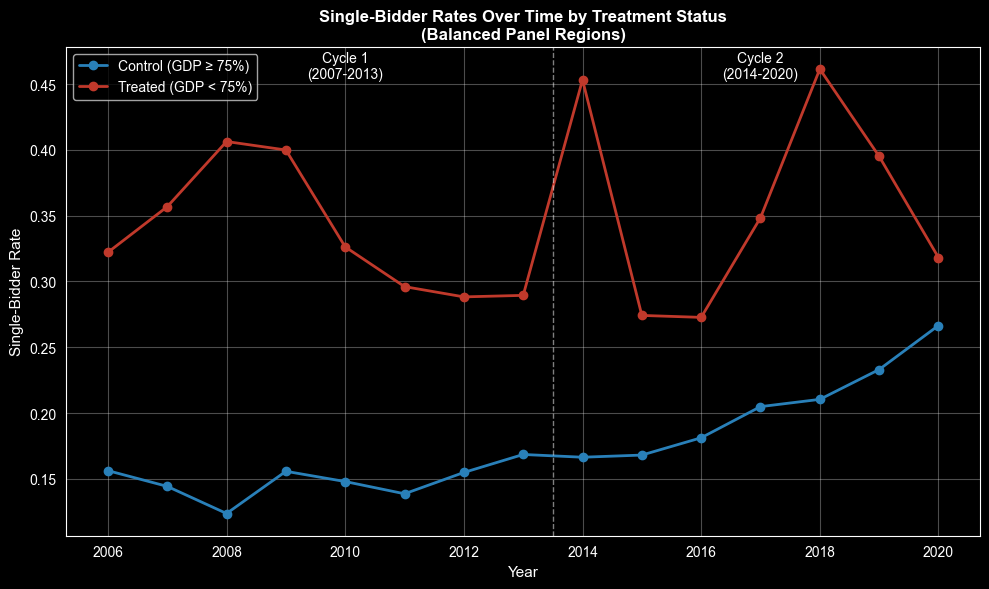

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR  = '/Users/matei/Documents/Classes/Economics/ECO 358R/Paper Proposal #1 (EU Aid v. Single Bids)/Data/Cleaned Data/'
TED_PATH  = DATA_DIR + "TED_Master_Cleaned_2006_2020.csv"

# Load TED data
ted = pd.read_csv(TED_PATH, dtype={"TAL_LOCATION_NUTS": str})
ted["single_bidder"] = (ted["NUMBER_OFFERS"] == 1).astype(int)

# Load cycle 2 treatment assignment
cs_c2 = pd.read_csv("analysis_dataset_cycle2.csv")
treatment_dict = dict(zip(cs_c2['nuts2'], cs_c2['treatment']))

# Aggregate by year and treatment
ted['treatment'] = ted['TAL_LOCATION_NUTS'].map(treatment_dict)
ted = ted[ted['treatment'].notna()]  # Keep only analyzed regions

yearly = ted.groupby(['YEAR', 'treatment'])['single_bidder'].mean().reset_index()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
for t in [0, 1]:
    data = yearly[yearly['treatment'] == t]
    label = "Treated (GDP < 75%)" if t == 1 else "Control (GDP ≥ 75%)"
    color = "#C0392B" if t == 1 else "#2980B9"
    ax.plot(data['YEAR'], data['single_bidder'],
            marker='o', linewidth=2, markersize=6,
            color=color, label=label)

ax.axvline(2013.5, color='white', linestyle='--', linewidth=1, alpha=0.5)
ax.text(2010, ax.get_ylim()[1]*0.95, 'Cycle 1\n(2007-2013)', ha='center', fontsize=10)
ax.text(2017, ax.get_ylim()[1]*0.95, 'Cycle 2\n(2014-2020)', ha='center', fontsize=10)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Single-Bidder Rate', fontsize=11)
ax.set_title('Single-Bidder Rates Over Time by Treatment Status\n(Balanced Panel Regions)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_sbr_time_series.png", dpi=150, bbox_inches='tight')

In [4]:
"""
Table 1 — Summary Statistics (Standalone)
Means, SDs, min, max for the 13 paper variables × treatment × cycle.
Loads everything from raw files; runs independently of the rest of the notebook.
"""

import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# 1. PATHS (edit DATA_DIR / OUT_DIR for your machine)
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR = '/Users/matei/Documents/Classes/Economics/ECO 358R/Paper Proposal #1 (EU Aid v. Single Bids)/Data/Cleaned Data/'
OUT_DIR  = DATA_DIR + 'output/'

PATHS = {
    "ted":        DATA_DIR + "TED_Master_Cleaned_2006_2020.csv",
    "gdp_main":   DATA_DIR + "GDP_per_capita_PPS.xlsx",
    "gdp_hist":   DATA_DIR + "nama_10r_2gdp__custom_21092031_spreadsheet.xlsx",
    "education":  DATA_DIR + "Education.xlsx",
    "population": DATA_DIR + "Population_density_by_NUTS2.xlsx",
    "services":   DATA_DIR + "Final_Service_Controls.xlsx",
    "agriculture":DATA_DIR + "Final_Agri_Controls.xlsx",
    "geo":        DATA_DIR + "nuts2_geographic_controls.csv",
    "gov_eff":    DATA_DIR + "gov_effectiveness.csv",
    "unemploy":   DATA_DIR + "unemployment_by_nuts2.csv",
}

CUTOFF = 75.0
EU_PREFIXES = ["AT","BE","BG","CY","CZ","DE","DK","EE","EL","ES","FI","FR",
               "GR","HR","HU","IE","IT","LT","LU","LV","MT","NL","PL","PT",
               "RO","SE","SI","SK"]

CYCLE_YEARS = {1: (2007, 2013), 2: (2014, 2020)}

# ─────────────────────────────────────────────────────────────────────────────
# 2. LOAD RAW SOURCES
# ─────────────────────────────────────────────────────────────────────────────

# TED procurement → region-year SBR
ted = pd.read_csv(PATHS["ted"], dtype={"TAL_LOCATION_NUTS": str})
ted["single_bidder"] = (ted["NUMBER_OFFERS"] == 1).astype(int)
ted_agg = (ted.groupby(["TAL_LOCATION_NUTS", "YEAR"])
              .agg(total_contracts=("NUMBER_OFFERS", "count"),
                   single_bidder_n=("single_bidder",  "sum"))
              .reset_index())
ted_agg["sbr"] = ted_agg["single_bidder_n"] / ted_agg["total_contracts"]
ted_agg = ted_agg.rename(columns={"TAL_LOCATION_NUTS": "nuts2", "YEAR": "year"})

# Main GDP (PPS) — used for Cycle 2 reference and for the Region→NUTS2 lookup
gdp_main = pd.read_excel(PATHS["gdp_main"])
gdp_main["PPS"]    = pd.to_numeric(gdp_main["PPS"], errors="coerce")
gdp_main["Region"] = gdp_main["Region"].str.strip()
nuts_lu  = gdp_main[["Region", "TAL_LOCATION_NUTS"]].drop_duplicates("Region")

# Cycle 1 reference GDP = avg 2000–2002 from the historical Eurostat sheet
hist_raw = pd.read_excel(PATHS["gdp_hist"], header=None)
hist = hist_raw.iloc[9:, [0, 1, 3, 5]].copy()
hist.columns = ["region_name", "gdp_2000", "gdp_2001", "gdp_2002"]
hist["region_name"] = hist["region_name"].astype(str).str.strip()
junk = ["Extra-Regio", "Special value", "Observation flags", ":", "b", "nan"]
hist = hist[~hist["region_name"].apply(lambda x: any(str(x).startswith(j) for j in junk))]
for c in ["gdp_2000", "gdp_2001", "gdp_2002"]:
    hist[c] = pd.to_numeric(hist[c].astype(str).str.replace(":", ""), errors="coerce")
hist["ref_gdp_c1"] = hist[["gdp_2000", "gdp_2001", "gdp_2002"]].mean(axis=1)
hist = (hist.merge(nuts_lu, left_on="region_name", right_on="Region", how="left")
            .dropna(subset=["ref_gdp_c1", "TAL_LOCATION_NUTS"])
            [["TAL_LOCATION_NUTS", "ref_gdp_c1"]]
            .rename(columns={"TAL_LOCATION_NUTS": "nuts2"}))

# Cycle 2 reference GDP = avg 2007–2009 from the main GDP file
c2_ref = (gdp_main[gdp_main["YEAR"].isin([2007, 2008, 2009])]
          .groupby("TAL_LOCATION_NUTS")["PPS"].mean()
          .reset_index()
          .rename(columns={"TAL_LOCATION_NUTS": "nuts2", "PPS": "ref_gdp_c2"}))

# Time-varying covariates — same loader the notebook uses
def load_cov(path, val_col, new_col):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()
    year_col = [c for c in df.columns if "year" in c.lower()][0]
    nuts_col = [c for c in df.columns if "NUTS" in c.upper()][0]
    df[val_col] = pd.to_numeric(df[val_col], errors="coerce")
    return df[[nuts_col, year_col, val_col]].rename(
        columns={nuts_col: "nuts2", year_col: "year", val_col: new_col})

edu  = load_cov(PATHS["education"],   "Education",         "educ_share")
pop  = load_cov(PATHS["population"],  "Pop_Dens",          "pop_density")
svc  = load_cov(PATHS["services"],    "Service_Share",     "Service_Share")
agri = load_cov(PATHS["agriculture"], "Agriculture_Share", "Agriculture_Share")

# Time-invariant / cycle-specific extras
geo_controls = pd.read_csv(PATHS["geo"])
gov_eff      = pd.read_csv(PATHS["gov_eff"])
unemployment = pd.read_csv(PATHS["unemploy"])

# ─────────────────────────────────────────────────────────────────────────────
# 3. BUILD ONE CYCLE-LEVEL CROSS-SECTION
# ─────────────────────────────────────────────────────────────────────────────
def build_cycle(cycle_id, ref_df, ref_col):
    y0, y1 = CYCLE_YEARS[cycle_id]
    years  = list(range(y0, y1 + 1))

    # Region-level SBR averaged across the cycle window
    sub = ted_agg[ted_agg["year"].isin(years)]
    panel = sub.groupby("nuts2").agg(
        sbr=("sbr", "mean"),
        total_contracts=("total_contracts", "sum")).reset_index()

    # Forcing variable + treatment
    panel = panel.merge(ref_df, on="nuts2", how="inner")
    panel["running_var"] = panel[ref_col] - CUTOFF
    panel["treatment"]   = (panel[ref_col] < CUTOFF).astype(int)
    panel["cycle"]       = cycle_id

    # Time-varying controls averaged across cycle years
    for src_df, col in [(edu, "educ_share"), (pop, "pop_density"),
                        (svc, "Service_Share"), (agri, "Agriculture_Share")]:
        avg = src_df[src_df["year"].isin(years)].groupby("nuts2")[col].mean().reset_index()
        panel = panel.merge(avg, on="nuts2", how="left")
    panel["log_pop_density"] = np.log1p(panel["pop_density"])

    # Geographic (time-invariant), gov effectiveness (cycle-specific), unemployment (cycle-specific)
    panel = panel.merge(geo_controls, on="nuts2", how="left")
    panel["country_code"] = panel["nuts2"].str[:2]
    ge_col = f"gov_effectiveness_c{cycle_id}_norm"
    un_col = f"unemployment_c{cycle_id}"
    panel = (panel.merge(gov_eff[["country_code", ge_col]], on="country_code", how="left")
                  .rename(columns={ge_col: "gov_effectiveness_norm"})
                  .merge(unemployment[["nuts2", un_col]], on="nuts2", how="left")
                  .rename(columns={un_col: "unemployment"}))

    # Same filters as the main script
    panel = panel[panel["nuts2"].str[:2].isin(EU_PREFIXES)]
    panel = panel.dropna(subset=["sbr", "running_var"])
    return panel

cs_c1 = build_cycle(1, hist,   "ref_gdp_c1")
cs_c2 = build_cycle(2, c2_ref, "ref_gdp_c2")

# Balanced panel: regions present in both cycles (matches main script)
common = set(cs_c1["nuts2"]) & set(cs_c2["nuts2"])
cs_c1  = cs_c1[cs_c1["nuts2"].isin(common)].copy()
cs_c2  = cs_c2[cs_c2["nuts2"].isin(common)].copy()
panel  = pd.concat([cs_c1, cs_c2], ignore_index=True)
print(f"  Balanced panel: {len(common)} regions × 2 cycles = {len(panel)} obs")

# ─────────────────────────────────────────────────────────────────────────────
# 4. SUMMARY STATISTICS — 13 variables × treatment × cycle
# ─────────────────────────────────────────────────────────────────────────────
SUMMARY_VARS = [
    ("sbr",                    "Single-bidder rate"),
    ("running_var",            "Running variable (GDP − 75)"),
    ("educ_share",             "Tertiary education (%)"),
    ("log_pop_density",        "Log population density"),
    ("Service_Share",          "Services share (% GDP)"),
    ("Agriculture_Share",      "Agriculture share (% GDP)"),
    ("dist_brussels_km",       "Distance to Brussels (km)"),
    ("dist_capital_km",        "Distance to capital (km)"),
    ("post_communist",         "Post-communist dummy"),
    ("mediterranean",          "Mediterranean dummy"),
    ("terrain_ruggedness",     "Terrain ruggedness"),
    ("gov_effectiveness_norm", "Government effectiveness"),
    ("unemployment",           "Unemployment rate (%)"),
]
assert len(SUMMARY_VARS) == 13, "Paper specifies 13 variables"

def _block(frame, cycle_lbl, group_lbl):
    out = []
    for col, pretty in SUMMARY_VARS:
        if col not in frame.columns:
            continue
        s = frame[col].dropna()
        out.append({
            "Cycle":    cycle_lbl,
            "Group":    group_lbl,
            "N":        len(s),
            "Variable": pretty,
            "Mean":     round(s.mean(), 4),
            "SD":       round(s.std(ddof=1), 4),
            "Min":      round(s.min(), 4),
            "Max":      round(s.max(), 4),
        })
    return out

rows = []
for c in (1, 2):
    cyc = panel[panel["cycle"] == c]
    rows += _block(cyc[cyc["treatment"] == 1], f"Cycle {c}", "Treated")
    rows += _block(cyc[cyc["treatment"] == 0], f"Cycle {c}", "Control")
    rows += _block(cyc,                         f"Cycle {c}", "All")
rows += _block(panel[panel["treatment"] == 1], "Pooled", "Treated")
rows += _block(panel[panel["treatment"] == 0], "Pooled", "Control")
rows += _block(panel,                           "Pooled", "All")

summary_df = pd.DataFrame(rows)
order = [p for _, p in SUMMARY_VARS]
summary_df["Variable"] = pd.Categorical(summary_df["Variable"], categories=order, ordered=True)
summary_df = summary_df.sort_values(["Cycle", "Group", "Variable"]).reset_index(drop=True)

out_path = OUT_DIR + "table1_summary_statistics.csv"
summary_df.to_csv(out_path, index=False)
print(f"  ✓ Wrote {out_path}")
print(f"    {len(summary_df)} rows = {len(SUMMARY_VARS)} vars × "
      f"{summary_df[['Cycle','Group']].drop_duplicates().shape[0]} (cycle × group) cells")

  Balanced panel: 143 regions × 2 cycles = 286 obs
  ✓ Wrote /Users/matei/Documents/Classes/Economics/ECO 358R/Paper Proposal #1 (EU Aid v. Single Bids)/Data/Cleaned Data/output/table1_summary_statistics.csv
    117 rows = 13 vars × 9 (cycle × group) cells
